# Selección de variables con pyWinEA para presión arterial media (MAP)

Este notebook usa **pyWinEA** para seleccionar variables mediante **Algoritmos Genéticos** sobre el dataset del proyecto ubicado en `data/`.

La variable objetivo se construye como **presión arterial media (MAP)**:

\[
MAP = \frac{SBP + 2 \cdot DBP}{3}
\]

donde `SBP` es la presión sistólica y `DBP` la presión diastólica.

> Nota metodológica: después de crear el target, se eliminan las columnas de presión sistólica/diastólica del conjunto de predictores para evitar *data leakage*.


In [2]:
%env SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True

env: SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True


In [3]:
%pip install pyWinEA

  Using cached pywinEA-0.0.2-py3-none-any.whl.metadata (6.4 kB)
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Created wheel for sklearn: filename=sklearn-0.0.post12-py3-none-any.whl size=2219 sha256=833a7905a732cdbc1ec97bbd4e0578e41c7545a2b0069ea00028020d194516d0
  Stored in directory: c:\users\usuario\appdata\local\pip\cache\wheels\df\a3\e3\6a1b9d42118569a572597a7422f9b58212f28fdaa9b18e8c10
Successfully built sklearn

   -------------------------- ------------- 2/3 [pyWinEA]
   ---------------------------------------- 3/3 [pyWinEA]

Note: you may

In [7]:
import pywinEA
print("pyWinEA ok")

pyWinEA ok


## 1. Cargar librerías e importar dataset

In [ ]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


In [4]:
# 2. Carga del dataset desde la carpeta data/

dataset_path = Path("trainset.csv")
targetset_path = Path("trainset_target.csv")
print(f"Dataset encontrado: {dataset_path}")

if dataset_path.suffix.lower() == ".csv":
    df_set = pd.read_csv(dataset_path)
    df_target = pd.read_csv(targetset_path)
else:
    raise ValueError(f"Formato no soportado: {dataset_path.suffix}")

print(df_set.shape)
df_set.head()


Dataset encontrado: trainset.csv
(1919, 69)


,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,tamano_manguito_pa_4.0,tamano_manguito_pa_5.0,estado_elastografia_1,tipo_sonda_elasto_b'M',tipo_sonda_elasto_b'XL',raza_etnia_2.0,raza_etnia_3.0,raza_etnia_4.0,raza_etnia_6.0,raza_etnia_7.0
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 2. División train-test y categóricas-numéricas

In [5]:
# Separar train y test
X_train, X_test, y_train, y_test = train_test_split(
    df_set,
    df_target,
    test_size=0.3,      # 30% para test
    random_state=42,    # reproducibilidad
    shuffle=True
)

# Ver tamaños
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(1343, 69)
(576, 69)
(1343, 1)
(576, 1)


In [ ]:
# Listas de variables numéricas y categóricas

# Variables categóricas:
# Se consideran categóricas todas aquellas binarias (0.0 y 1.0)
categorical_cols = [
    col for col in X_train.columns
    if set(X_train[col].dropna().unique()).issubset({0.0, 1.0})
]

# Variables numéricas:
# Todas las demás variables
numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

# Comprobación rápida
print(f"Variables categóricas: {len(categorical_cols)}")
print(f"Variables numéricas: {len(numerical_cols)}")

# Mostrar ejemplos
print("\nPrimeras categóricas:")
print(categorical_cols[:10])

print("\nPrimeras numéricas:")
print(numerical_cols[:10])

In [6]:
# Variables categóricas:
# Se consideran categóricas todas aquellas binarias (0.0 y 1.0)
categorical_cols = [
    col for col in X_train.columns
    if set(X_train[col].dropna().unique()).issubset({0.0, 1.0})
]

# Variables numéricas:
# Todas las demás variables
numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

# Comprobación rápida
print(f"Variables categóricas: {len(categorical_cols)}")
print(f"Variables numéricas: {len(numerical_cols)}")

# Mostrar ejemplos
print("\nPrimeras categóricas:")
print(categorical_cols[:10])

print("\nPrimeras numéricas:")
print(numerical_cols[:10])

Variables categóricas: 23
Variables numéricas: 46

Primeras categóricas:
['genero_1', 'periodo_examen_1', 'pais_nacimiento_1', 'toma_suplementos_1', 'toma_antiacidos_1', 'estado_examen_balance_1', 'elegibilidad_balance_1', 'convulsiones_1', 'caidas_1', 'fracturas_1']

Primeras numéricas:
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg']


> Como ya hicimos el preprocesamiento en el cuaderno `missForest_imp_tfm` no es necesario volver a realizar otro

## 8. Selección de variables con pyWinEA

La librería implementa algoritmos genéticos compatibles con modelos de `scikit-learn`. En esta versión del notebook usamos una tarea de **clasificación** (`target_map_alta`) porque es el flujo más estable de la API pública de pyWinEA.

El target continuo `map_mmHg` queda creado igualmente, por si después se quiere plantear una versión de regresión.


In [9]:
# Selección de variables con pyWinEA
import joblib
try:
    from pywinEA.algorithm import GA
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install git+https://github.com/FernandoGaGu/pywinEA.git
    from pywinEA.algorithm import GA

from sklearn.linear_model import LogisticRegression

fitness_model = LogisticRegression(
    max_iter=100,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE
)

POPULATION_SIZE = 300
GENERATIONS = 50
CV = 5
ANNIHILATION = 0.10
ELITISM = 0.15
MUTATION_RATE = 0.05

ga = GA(
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    cv=CV,
    fitness=fitness_model,
    annihilation=ANNIHILATION,
    elitism=ELITISM,
    mutation_rate=MUTATION_RATE,
    positive_class=1,
    id="GA_MAP_alta"
)

ga.set_features(X_train.columns.tolist())

ga.fit(
    X_train.values,
    y_train.values.ravel()
)

selected_features = list(ga.best_features)

print(f"Nº variables originales procesadas: {X_train.shape[1]}")
print(f"Nº variables seleccionadas por pyWinEA: {len(selected_features)}")

selected_features[:50]

# Guardar algoritmo genético completo
joblib.dump(ga,"ga_model.pkl")


 (BasicGA) Generations (form 0 to 50): 100%|██████████| 50/50 [07:08<00:00,  8.58s/it]

Nº variables originales procesadas: 69
Nº variables seleccionadas por pyWinEA: 28


['ga_model.pkl']

## Evaluación

A continuación vamos a comprobar con un modelo simple si la selección de variables que ha realizado el `ga` obtiene mejores resultados.

In [ ]:
# 9. Evaluación comparativa:
#    todas las variables vs variables seleccionadas por pyWinEA

def evaluar_clasificador(nombre, X_train_eval, X_test_eval, y_train, y_test):
    modelo = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )
    modelo.fit(X_train_eval, y_train)
    pred = modelo.predict(X_test_eval)

    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(X_test_eval)[:, 1]
        roc = roc_auc_score(y_test, proba)
    else:
        roc = np.nan

    return {
        "modelo": nombre,
        "n_variables": X_train_eval.shape[1],
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc
    }

resultados = []

resultados.append(
    evaluar_clasificador(
        "Todas_las_variables",
        X_train,
        X_test,
        y_train,
        y_test
    )
)

resultados.append(
    evaluar_clasificador(
        "pyWinEA_variables_seleccionadas",
        X_train[selected_features],
        X_test[selected_features],
        y_train,
        y_test
    )
)

df_resultados = pd.DataFrame(resultados).sort_values("roc_auc", ascending=False)
df_resultados


,modelo,n_variables,accuracy,f1,roc_auc
0,Todas_las_variables,69,0.635417,0.556962,0.691049
1,pyWinEA_variables_seleccionadas,28,0.631944,0.565574,0.673168


In [11]:
# ============================================================
# 10. Guardado de resultados
# ============================================================

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

selected_features_path = OUTPUT_DIR / "variables_seleccionadas_pyWinEA_MAP.csv"
resultados_path = OUTPUT_DIR / "resultados_pyWinEA_MAP.csv"

pd.Series(selected_features, name="variable").to_csv(selected_features_path, index=False)
df_resultados.to_csv(resultados_path, index=False)

print(f"Variables seleccionadas guardadas en: {selected_features_path}")
print(f"Resultados guardados en: {resultados_path}")


Variables seleccionadas guardadas en: outputs\variables_seleccionadas_pyWinEA_MAP.csv
Resultados guardados en: outputs\resultados_pyWinEA_MAP.csv


In [12]:
# ============================================================
# 11. Importancia de variables seleccionadas
# ============================================================

modelo_final = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

modelo_final.fit(X_train[selected_features], y_train)

importancias = pd.DataFrame({
    "variable": selected_features,
    "importancia": modelo_final.feature_importances_
}).sort_values("importancia", ascending=False)

importancias_path = OUTPUT_DIR / "importancias_variables_pyWinEA_MAP.csv"
importancias.to_csv(importancias_path, index=False)

print(f"Importancias guardadas en: {importancias_path}")
importancias.head(30)


Importancias guardadas en: outputs\importancias_variables_pyWinEA_MAP.csv


,variable,importancia
22,edad_an,0.080227
25,peso_kg,0.073417
4,albumina_orina_mg_l,0.065677
18,pulso,0.058335
1,hemoglobina_g_dl,0.058058
5,peso_flebotomia,0.052228
12,cadmio_sangre_nmol_l,0.051075
9,rigidez_mediana_kpa,0.050445
10,plomo_sangre_umol_l,0.049855
16,plaquetas_totales,0.046662


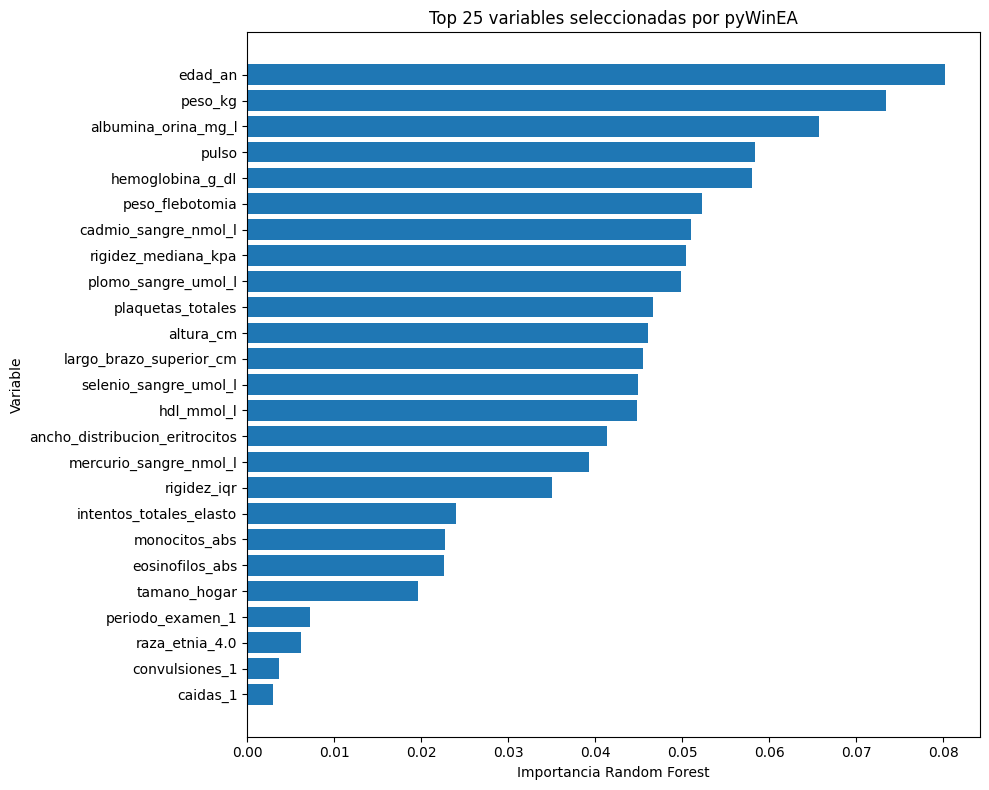

In [13]:
# ============================================================
# 12. Visualización rápida
# ============================================================

import matplotlib.pyplot as plt

top_n = 25
top_importancias = importancias.head(top_n).sort_values("importancia", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_importancias["variable"], top_importancias["importancia"])
plt.title(f"Top {top_n} variables seleccionadas por pyWinEA")
plt.xlabel("Importancia Random Forest")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


## Interpretación práctica

- `map_mmHg` representa la presión arterial media estimada a partir de presión sistólica y diastólica.
- `target_map_alta` transforma esa presión media en una variable binaria para selección genética con clasificadores.
- pyWinEA busca subconjuntos de variables que maximicen el rendimiento del modelo usado como `fitness`.
- La comparación final permite ver si el subconjunto seleccionado mantiene o mejora el rendimiento respecto a usar todas las variables.
- Las variables seleccionadas quedan guardadas en `outputs/variables_seleccionadas_pyWinEA_MAP.csv`.
